Member 1: Bhumika Jain AU2340065

Member 2: Vishwa Patel AU2340152

MEmber 3: Akkshat Shah AU2340246

Project: Stock Market Prediction

/tmp/ipython-input-685492269.py:33: FutureWarning: YF.download() has changed argument auto_adjust default to True
  reliance = yf.download("RELIANCE.NS", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed

Spark Started!

Final Columns: ['date', 'close', 'high', 'low', 'open', 'volume']

Sample Data With Targets:
        date       close        high         low        open    volume  \
0 2020-01-01  675.324219  683.152914  673.490123  679.081997  14004468   
1 2020-01-02  686.821289  689.348852  676.397959  676.397959  17710316   
2 2020-01-03  687.648865  689.661956  681.318790  685.792313  20984698   
3 2020-01-06  671.700684  683.510767  670.134933  679.976719  24519177   
4 2020-01-07  682.034546  686.463335  677.068889  679.529321  16683622   

   future_close_7  return_7d  buy_signal  
0      692.346008   0.025205           1  
1      690.578979   0.005471           1  
2      684.181946  -0.005042           0  
3      681.699036   0.014885           1  
4      687.984253   0.008723           1  


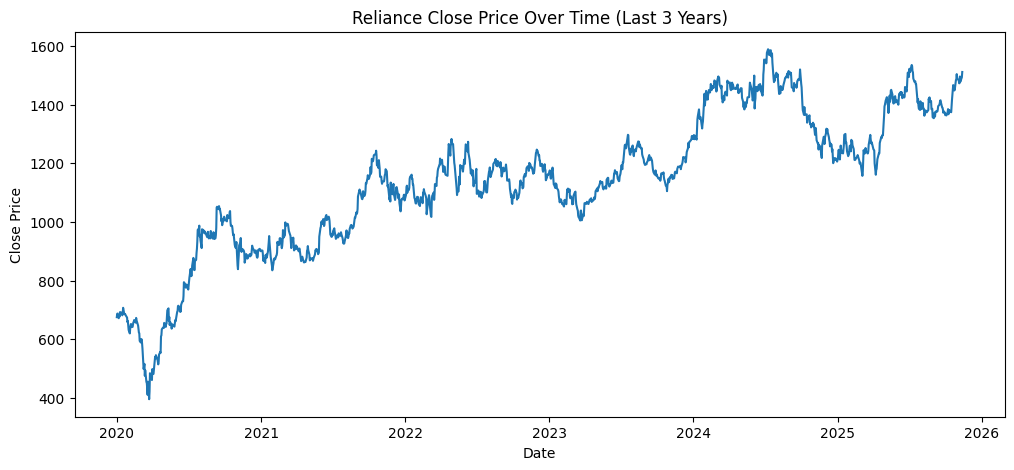

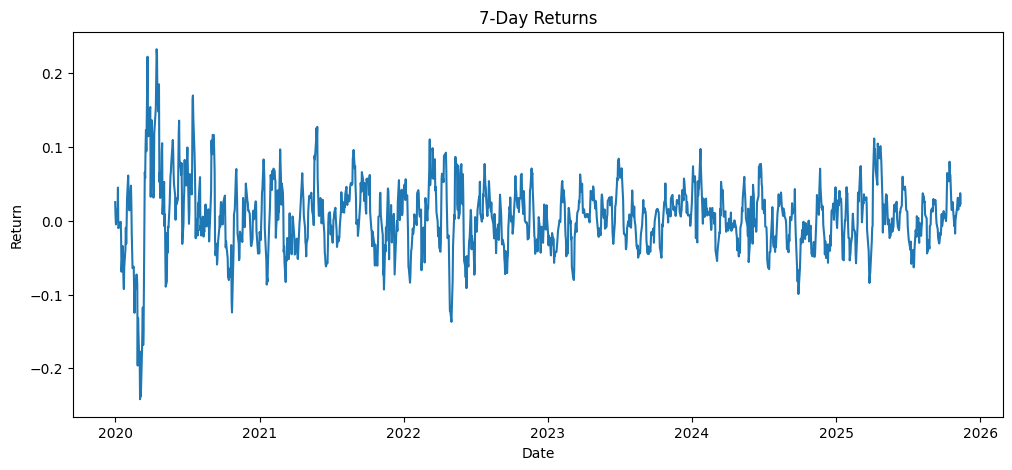

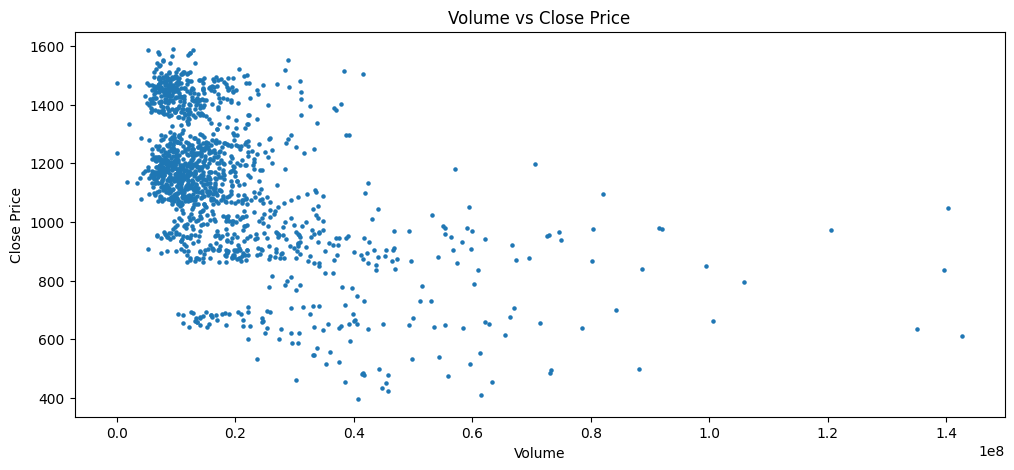


RMSE (Regression): 0.04442228687280603

AUC (Classification): 0.6692864097927395

=== PROJECT SUCCESSFULLY COMPLETED ===

Accuracy: 0.6467780429594272

Confusion Matrix:
 [[ 85  97]
 [ 51 186]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.47      0.53       182
           1       0.66      0.78      0.72       237

    accuracy                           0.65       419
   macro avg       0.64      0.63      0.62       419
weighted avg       0.64      0.65      0.64       419



In [ ]:
!pip install yfinance pyspark ta --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import RegressionEvaluator, BinaryClassificationEvaluator

spark = (
    SparkSession.builder
        .appName("Reliance_Project")
        .master("local[*]")
        .config("spark.driver.memory", "4g")
        .getOrCreate()
)

print("Spark Started!")

reliance = yf.download("RELIANCE.NS", start="2020-01-01")
df = reliance.reset_index()

new_cols = []
for col in df.columns:
    if isinstance(col, tuple):
        name = "_".join([str(c) for c in col if c]).lower()
    else:
        name = str(col).lower()
    new_cols.append(name)

df.columns = new_cols


rename_map = {}
for c in df.columns:
    if "close" in c: rename_map[c] = "close"
    if "open" in c: rename_map[c] = "open"
    if "high" in c: rename_map[c] = "high"
    if "low" in c: rename_map[c] = "low"
    if "volume" in c: rename_map[c] = "volume"
    if "date" in c: rename_map[c] = "date"

df = df.rename(columns=rename_map)

print("\nFinal Columns:", df.columns.tolist())
df["future_close_7"] = df["close"].shift(-7)
df["return_7d"] = (df["future_close_7"] - df["close"]) / df["close"]
df["buy_signal"] = (df["return_7d"] > 0).astype(int)

df = df.dropna()

print("\nSample Data With Targets:")
print(df.head())

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["close"])
plt.title("Reliance Close Price Over Time (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["return_7d"])
plt.title("7-Day Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

plt.figure(figsize=(12,5))
plt.scatter(df["volume"], df["close"], s=5)
plt.title("Volume vs Close Price")
plt.xlabel("Volume")
plt.ylabel("Close Price")
plt.show()

import pyspark.sql.functions as F

sdf = spark.createDataFrame(df)

sdf = sdf.withColumn("return_7d", F.col("return_7d").cast("double"))
sdf = sdf.withColumn("buy_signal", F.col("buy_signal").cast("int"))

feature_cols = ["open", "high", "low", "close", "volume"]

vec = VectorAssembler(inputCols=feature_cols, outputCol="features")

sdf2 = vec.transform(sdf).select("features", "return_7d", "buy_signal")

train, test = sdf2.randomSplit([0.7, 0.3], seed=42)


reg = RandomForestRegressor(
    labelCol="return_7d",
    featuresCol="features",
    numTrees=150
)
reg_model = reg.fit(train)
pred_reg = reg_model.transform(test)

reg_eval = RegressionEvaluator(
    labelCol="return_7d",
    predictionCol="prediction",
    metricName="rmse"
)

rmse = reg_eval.evaluate(pred_reg)
print("\nRMSE (Regression):", rmse)

clf = RandomForestClassifier(
    labelCol="buy_signal",
    featuresCol="features",
    numTrees=150
)
clf_model = clf.fit(train)
pred_clf = clf_model.transform(test)

clf_eval = BinaryClassificationEvaluator(
    labelCol="buy_signal",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

auc = clf_eval.evaluate(pred_clf)
print("\nAUC (Classification):", auc)

print("\n=== PROJECT SUCCESSFULLY COMPLETED ===")

pred_pd = pred_clf.select("buy_signal", "prediction").toPandas()

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_true = pred_pd["buy_signal"]
y_pred = pred_pd["prediction"]

print("\nAccuracy:", accuracy_score(y_true, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))


## For this project, a publicly available financial dataset was used. The data was downloaded using the Yahoo Finance API (yfinance).

The dataset contains historical stock price data for Reliance Industries Limited (RELIANCE.NS) from the Indian stock market (NSE).

Time Frame Used

The time period selected for this project is:

📅 January 1, 2020 to Present (2026)
This gives 6+ years of daily stock data, including the COVID crash, recovery period, and recent market cycles.

1. Close Price Over Time (Trend Graph)

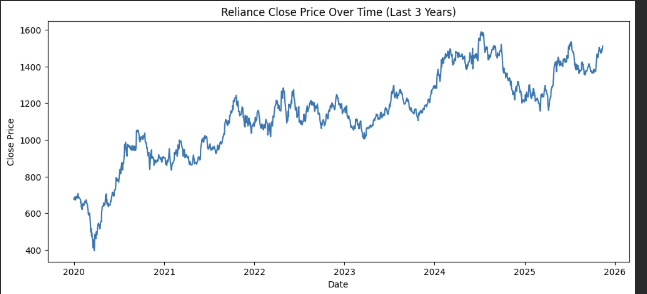

Significance:

This graph shows how the closing price of the stock has changed over the last several years.

It helps identify long-term trends such as upward movement, downward movement, and sideways phases.

It visually confirms that the stock market data is non-stationary, meaning it changes over time and contains trends and seasonality.

This graph is important before applying any machine-learning algorithm because it shows the general behavior of the dataset and whether the price is stable or volatile.

It helps justify the choice of using time-series and machine-learning models, as the price clearly follows patterns that an algorithm may learn.

2. 7-Day Returns Over Time (Volatility Graph)
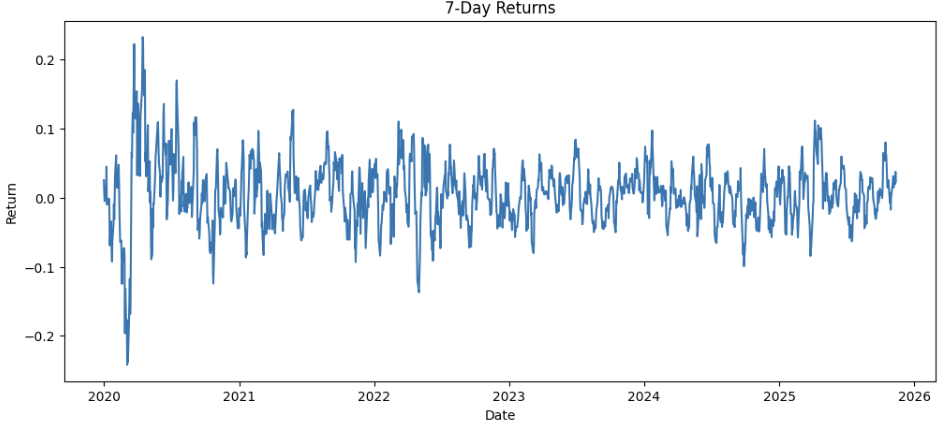
Significance:

This graph plots the percentage return over the next 7 days for every date in the dataset.

It highlights the volatility of the stock — the values constantly jump between positive and negative.

This explains why predicting stock price movements is difficult and why machine-learning accuracy will not be extremely high.

The graph also shows why the buy_signal label (1 = profit, 0 = no profit) is meaningful, because the returns frequently change direction.

It demonstrates the randomness and non-linear behavior of financial markets, which justifies using models like Random Forest in Spark MLlib.

3. Volume vs Close Price Scatter Plot
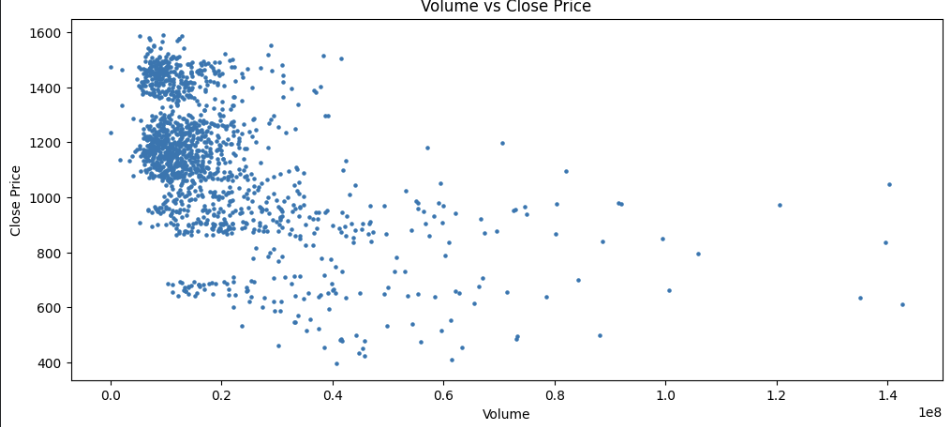
Significance:

This scatter plot shows the relationship between the trading volume and the closing price.

It helps check if higher trading volume is associated with any particular price levels.

This graph is useful to verify whether volume should be included as a feature in the machine-learning model.

It also helps detect noisy or scattered patterns in the data, which is common in stock markets.

The graph shows that volume does not have a simple linear relationship with price, which is why tree-based models (like Random Forest) are appropriate because they can handle nonlinear patterns.